In [1]:
import numpy as np

"""
Exercise 4: NumPy Array Operations
"""

# Task 1 : Create a 5 x 5 matrix where border elements are 1 and interior is 0
matrix = np.ones((5, 5))
matrix[1:-1, 1:-1] = 0

print("Task 1 – Border matrix:")
print(matrix)

# Task 2: Normalize a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)

# Task 3: Implementing  linaer regression solution using normal equation
col_means = random_data.mean(axis=0)
col_stds  = random_data.std(axis=0)
normalized = (random_data - col_means) / col_stds

print("\nTask 2 – Normalized column stats:")
print("  Means (should be ~0):", normalized.mean(axis=0).round(10))
print("  Stds  (should be  1):", normalized.std(axis=0).round(10))


np.random.seed(42)
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

XtX     = X.T @ X
XtX_inv = np.linalg.inv(XtX)
Xty     = X.T @ y
theta_hat = XtX_inv @ Xty

print("\nTask 3 – Normal equation coefficients:")
print(f"  True theta : {true_theta}")
print(f"  Theta hat  : {theta_hat.round(4)}")
print(f"  Difference : {(theta_hat - true_theta).round(4)}")

Task 1 – Border matrix:
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

Task 2 – Normalized column stats:
  Means (should be ~0): [-0.  0. -0.]
  Stds  (should be  1): [1. 1. 1.]

Task 3 – Normal equation coefficients:
  True theta : [ 2.5 -1.2  3.7]
  Theta hat  : [ 2.5123 -1.215   3.6992]
  Difference : [ 0.0123 -0.015  -0.0008]


In [6]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan


# Task 1 - Data Cleaning and exploration
print("=" * 55)
print("TASK 1 – Data Cleaning & Exploration")
print("=" * 55)

# Basic info
print("\n── df.info() ──")
df.info()

print("\n── First 5 rows ──")
print(df.head())

print("\n── Descriptive statistics ──")
print(df.describe().round(2))

# Missing values
missing = df.isnull().sum()
print("\n── Missing value counts ──")
print(missing[missing > 0])

df['exam_score'] = df.groupby('major')['exam_score'] \
.transform(lambda s: s.fillna(s.mean()))

df['hours_studied'] = df.groupby('year')['hours_studied'] \
                        .transform(lambda s: s.fillna(s.median()))


print("\n── Missing values after imputation ──")
print(df.isnull().sum())


# Task 2 - Analysis

print("\n" + "=" * 55)
print("TASK 2 - Analysis")
print("=" * 55)

# Average exams_score by major.
avg_by_major = df.groupby('major')['exam_score'].mean().round(2).sort_values(ascending=False)
print("\n__ Average exam score by major")
print(avg_by_major)

best_major = avg_by_major.idxmax()
print(f"\nMajor with highest average exam score : {best_major} {avg_by_major[best_major]:.2f}")

correlation = df['hours_studied'].corr(df['exam_score'])
print(f"\nCorrelation (hour_Studied : exam_score) : {correlation:.4f}")

def categorise(score):
  if score > 90:
    return "Excllent"
  elif score > 80:
    return "Good"
  elif score > 70:
    return "Average"
  else:
    return "Needs Improvement"


df["performance"] = df["exam_score"].apply(categorise)

print("-----Performane distribution-----")
print(df["performance"].value_counts())


#Task 3 - Advanced analysis
print("\n" + "=" * 55)
print("TASK 3 – Advanced Analysis")
print("=" * 55)

group_stats = (
    df.groupby(['major', 'year'])
      .agg(
          n_students    = ('student_id',   'count'),
          avg_exam      = ('exam_score',   'mean'),
          avg_hours     = ('hours_studied','mean'),
      )
      .round(2)
)
print("\n── Stats by major & year ──")
print(group_stats.to_string())

print("\n── Stats by major & year ──")
print(group_stats.to_string())

df['rank'] = df['exam_score'].rank(method='min', ascending=False)
top5 = (df[df['rank'] <= 5]
          .sort_values('rank')[['rank','student_id','major','year','exam_score']]
          .reset_index(drop=True))
print("\n── Top 5 students (ties included) ──")
print(top5.to_string(index=False))

pivot = df.pivot_table(
    values  = 'exam_score',
    index   = 'major',
    columns = 'year',
    aggfunc = 'mean',
).round(2)
pivot.columns = [f'Year {y}' for y in pivot.columns]
print("------ Pivot table: avg exam score (major × year) -----")
print(pivot.to_string())





TASK 1 – Data Cleaning & Exploration

── df.info() ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB

── First 5 rows ──
   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1

/tmp/ipykernel_1083/1452615624.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="major", y="exam_score",palette=MAJOR_PALETTE, linewidth=1.2,order=['CS', 'Math', 'Physics', 'Biology'], ax=ax2)


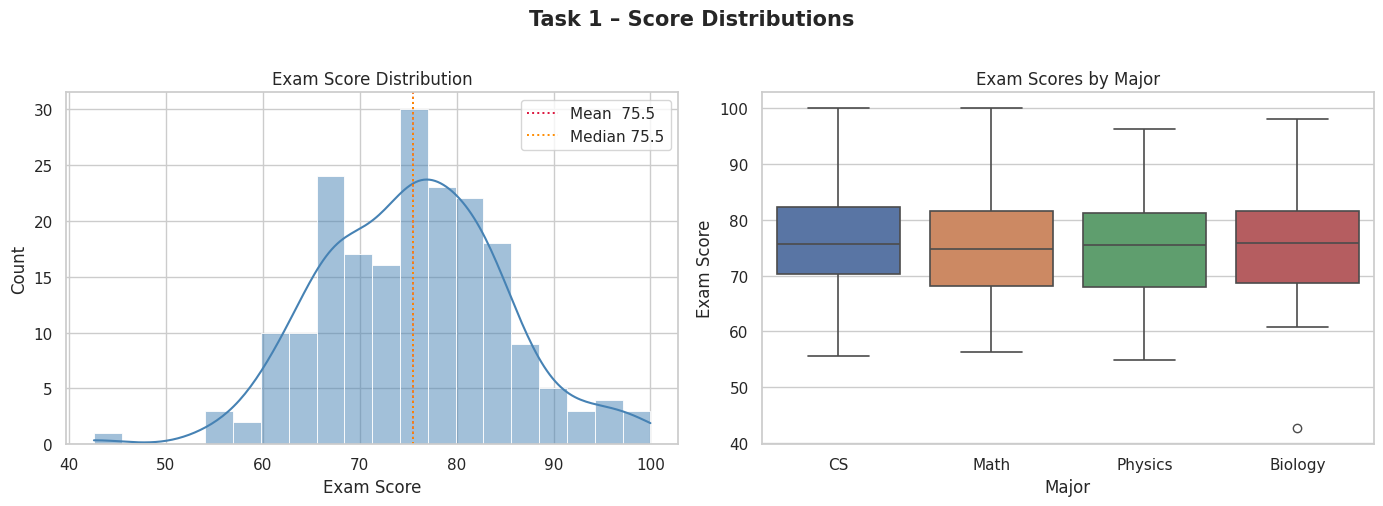

Saved : task1_distributions.png


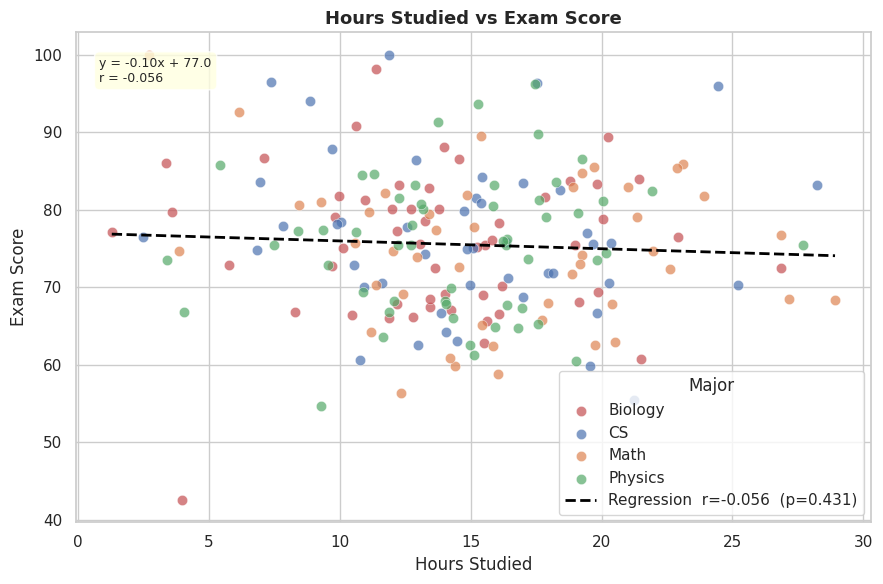

Saved → task2_scatter.png


/tmp/ipykernel_1083/1452615624.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="performance", y="exam_score",order=PERF_ORDER, palette=PERF_PALETTE,


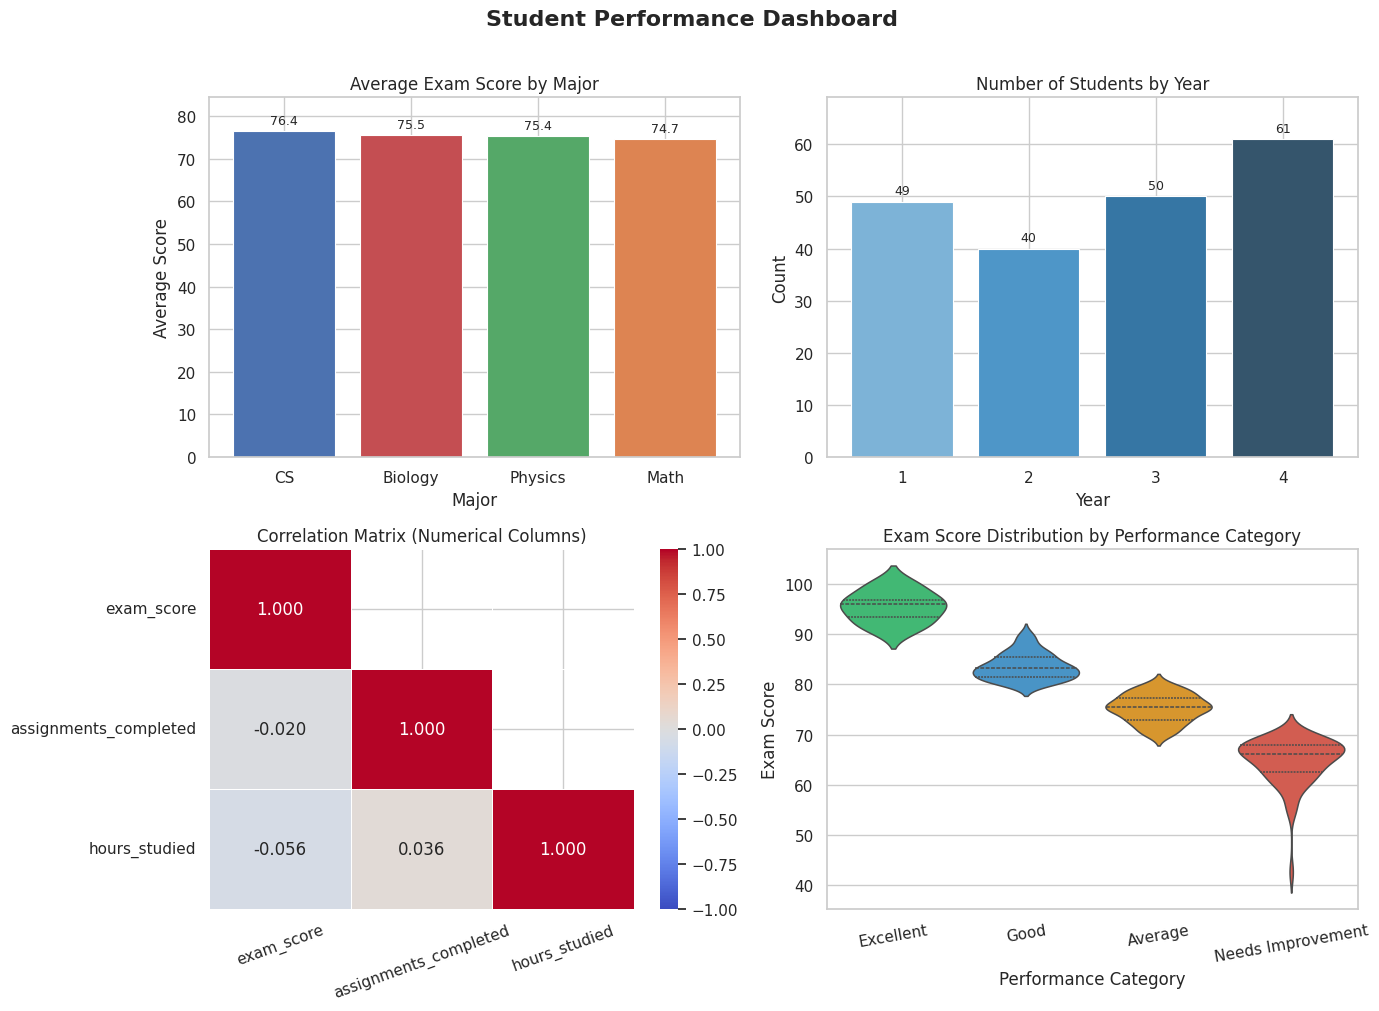

Saved : task3_dashboard.png


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

# ----- Recreate df from Exercise 5 ----------
np.random.seed(42)
n_students = 200
data = {
    'student_id':            range(1000, 1000 + n_students),
    'major':                 np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year':                  np.random.choice([1, 2, 3, 4], n_students),
    'exam_score':            np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied':         np.random.normal(15, 5, n_students).clip(1, 40),
}
df = pd.DataFrame(data)
df.loc[np.random.choice(n_students, 10), 'exam_score']    = np.nan
df.loc[np.random.choice(n_students, 5),  'hours_studied'] = np.nan
df['exam_score']   = df.groupby('major')['exam_score'].transform(lambda s: s.fillna(s.mean()))
df['hours_studied']= df.groupby('year')['hours_studied'].transform(lambda s: s.fillna(s.median()))

def categorise(score):
    if   score > 90:
      return "Excellent"
    elif score > 80:
      return "Good"
    elif score > 70:
      return "Average"
    else:
      return "Needs Improvement"
df["performance"] = df["exam_score"].apply(categorise)


sns.set_theme(style="whitegrid", palette="muted")
MAJOR_PALETTE = {"CS": "#4C72B0", "Math": "#DD8452", "Physics": "#55A868", "Biology": "#C44E52"}
PERF_ORDER    = ["Excellent", "Good", "Average", "Needs Improvement"]
PERF_PALETTE  = ["#2ecc71",   "#3498db", "#f39c12",  "#e74c3c"]


# TASK 1 – Distribution Visualisation
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle('Task 1 – Score Distributions', fontsize=15, fontweight='bold', y=1.01)


sns.histplot(df["exam_score"], bins=20, kde=True, color='steelblue',edgecolor='white', linewidth=0.6, ax=ax1)
ax1.axvline(df["exam_score"].mean(),   color="crimson",    linestyle=":", linewidth=1.4, label=f"Mean  {df['exam_score'].mean():.1f}")
ax1.axvline(df["exam_score"].median(), color="darkorange", linestyle=":",  linewidth=1.4, label=f"Median {df['exam_score'].median():.1f}")
ax1.set_title("Exam Score Distribution")
ax1.set_xlabel("Exam Score")
ax1.set_ylabel("Count")
ax1.legend()


sns.boxplot(data=df, x="major", y="exam_score",palette=MAJOR_PALETTE, linewidth=1.2,order=['CS', 'Math', 'Physics', 'Biology'], ax=ax2)
ax2.set_title("Exam Scores by Major")
ax2.set_xlabel("Major")
ax2.set_ylabel("Exam Score")

plt.tight_layout()
plt.savefig("task1_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved : task1_distributions.png")


# TASK 2 – Relationship Visualisation
fig2, ax = plt.subplots(figsize=(9, 6))

for major, grp in df.groupby('major'):
    ax.scatter(grp["hours_studied"], grp["exam_score"],color=MAJOR_PALETTE[major], label=major,alpha=0.7, edgecolors="white", linewidth=0.4, s=55)


slope, intercept, r, p, _ = stats.linregress(df["hours_studied"], df["exam_score"])
x_line = np.linspace(df["hours_studied"].min(), df["hours_studied"].max(), 200)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="black", linewidth=2, linestyle='--',label=f"Regression  r={r:.3f}  (p={p:.3f})")

# Annotation box
ax.text(0.03, 0.95,f'y = {slope:.2f}x + {intercept:.1f}\nr = {r:.3f}',transform=ax.transAxes, fontsize=9,verticalalignment='top',bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

ax.set_title("Hours Studied vs Exam Score", fontsize=13, fontweight="bold")
ax.set_xlabel("Hours Studied")
ax.set_ylabel("Exam Score")
ax.legend(title="Major", loc="lower right")

plt.tight_layout()
plt.savefig("task2_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → task2_scatter.png")


# TASK 3 – Advanced 2×2 Dashboard
fig3, axes = plt.subplots(2, 2, figsize=(14, 10))
fig3.suptitle("Student Performance Dashboard", fontsize=16, fontweight= "bold", y=1.01)

avg_scores = df.groupby("major")["exam_score"].mean().sort_values(ascending=False)
bars = axes[0, 0].bar(avg_scores.index, avg_scores.values,color=[MAJOR_PALETTE[m] for m in avg_scores.index],edgecolor='white', linewidth=0.8)

axes[0, 0].bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
axes[0, 0].set_title("Average Exam Score by Major")
axes[0, 0].set_xlabel("Major")
axes[0, 0].set_ylabel("Average Score")
axes[0, 0].set_ylim(0, avg_scores.max() + 8)


year_counts = df["year"].value_counts().sort_index()
bars2 = axes[0, 1].bar(year_counts.index.astype(str), year_counts.values,color=sns.color_palette('Blues_d', 4),edgecolor='white', linewidth=0.8)
axes[0, 1].bar_label(bars2, padding=3, fontsize=9)
axes[0, 1].set_title("Number of Students by Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_ylim(0, year_counts.max() + 8)


num_cols  = ["exam_score", "assignments_completed", "hours_studied"]
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm",vmin=-1, vmax=1, linewidths=0.5,mask=mask,ax=axes[1, 0])
axes[1, 0].set_title("Correlation Matrix (Numerical Columns)")
axes[1, 0].tick_params(axis='x', rotation=20)
axes[1, 0].tick_params(axis='y', rotation=0)

sns.violinplot(data=df, x="performance", y="exam_score",order=PERF_ORDER, palette=PERF_PALETTE,
               inner="quartile", linewidth=1.1, ax=axes[1, 1])
axes[1, 1].set_title("Exam Score Distribution by Performance Category")
axes[1, 1].set_xlabel("Performance Category")
axes[1, 1].set_ylabel("Exam Score")
axes[1, 1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig("task3_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved : task3_dashboard.png")




── CLV summary ──
count     500.00
mean      743.76
std       349.91
min         0.00
25%       481.94
50%       712.26
75%       969.63
max      1645.71
Name: CLV, dtype: float64

── Age-group stats ──
           n_customers  avg_income  avg_CLV  total_CLV
age_group                                             
18-25               81    50634.02   718.37   58188.06
26-35               73    48747.15   747.74   54584.92
36-50              160    48516.90   732.80  117247.46
51-70              186    50713.16   762.69  141860.99

── Top 10 % threshold: £1222.94 ──
   50 customers qualify

── Top-10 % profile ──
         age    income  purchase_frequency  avg_purchase_value      CLV
count  50.00     50.00               50.00               50.00    50.00
mean   47.90  47864.94                7.68              137.57  1398.89
std    13.35  17862.38                1.49               17.52   110.59
min    20.00  15000.00                5.00              108.86  1234.07
25%    40.00  36404.71 

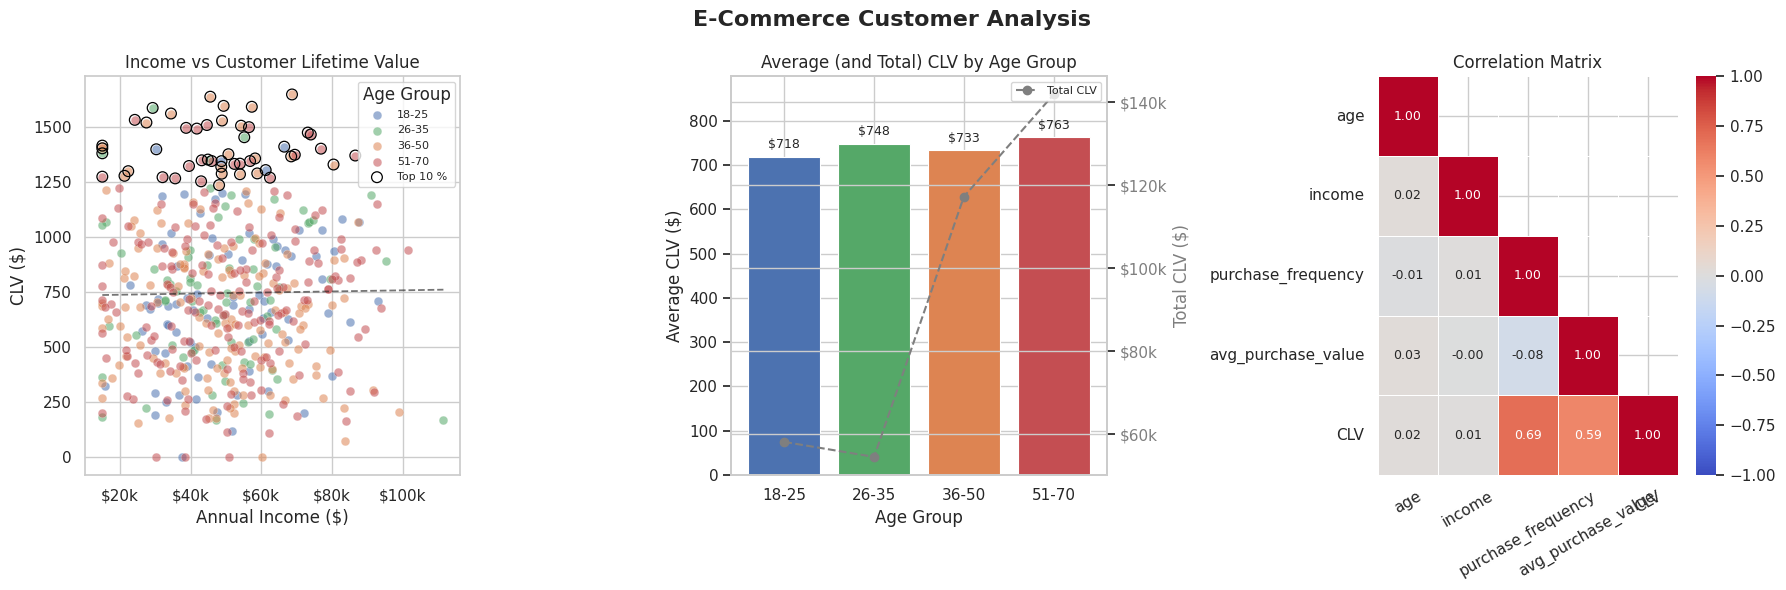


Saved : exercise7_dashboard.png


In [13]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----- Data generation (unchanged) -----------------------
np.random.seed(42)
n_customers = 500

ages               = np.random.randint(18, 70, n_customers)
income             = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq      = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age':                ages,
    'income':             income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value,
})



# STEP 1 – Customer Lifetime Value (CLV)
max_freq = customers['purchase_frequency'].max()

customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_freq)
customers['CLV']        = (customers['purchase_frequency']
                           * customers['avg_purchase_value']
                           * (1 + customers['churn_risk']))

print("── CLV summary ──")
print(customers['CLV'].describe().round(2))


# STEP 2 – Age groups
bins   = [17, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']

customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels)

AGE_PALETTE = {
    '18-25': '#4C72B0',
    '26-35': '#55A868',
    '36-50': '#DD8452',
    '51-70': '#C44E52',
}


# STEP 3 – Per-age-group stats

group_stats = (
    customers.groupby('age_group', observed=True)
             .agg(
                 n_customers = ('age',    'count'),
                 avg_income  = ('income', 'mean'),
                 avg_CLV     = ('CLV',    'mean'),
                 total_CLV   = ('CLV',    'sum'),
             )
             .round(2)
)
print("\n── Age-group stats ──")
print(group_stats.to_string())


# STEP 4 – Top 10 % by CLV

clv_threshold  = customers['CLV'].quantile(0.90)
top_customers  = customers[customers['CLV'] >= clv_threshold].copy()

print(f"\n── Top 10 % threshold: £{clv_threshold:.2f} ──")
print(f"   {len(top_customers)} customers qualify")
print("\n── Top-10 % profile ──")
print(top_customers[['age', 'income', 'purchase_frequency','avg_purchase_value', 'CLV']].describe().round(2))


# STEP 5 – Visualisations
sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('E-Commerce Customer Analysis', fontsize=16, fontweight='bold')

# --------- Plot 1: Income vs CLV scatter (coloured by age group) --------------
ax1 = axes[0]
for grp, subset in customers.groupby('age_group', observed=True):
    ax1.scatter(subset['income'], subset['CLV'],color=AGE_PALETTE[grp], label=grp,alpha=0.55, edgecolors='white', linewidth=0.3, s=40)

# Highlight top-10 % with a ring
ax1.scatter(top_customers['income'], top_customers['CLV'],facecolors='none', edgecolors='black',linewidth=0.9, s=60, label='Top 10 %', zorder=5)

# Overall trend line
m, b = np.polyfit(customers['income'], customers['CLV'], 1)
x_line = np.linspace(customers['income'].min(), customers['income'].max(), 200)
ax1.plot(x_line, m * x_line + b, 'k--', linewidth=1.3, alpha=0.6)

ax1.set_title('Income vs Customer Lifetime Value')
ax1.set_xlabel('Annual Income ($)')
ax1.set_ylabel('CLV ($)')
ax1.legend(title='Age Group', fontsize=8)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# ------------- Plot 2: Average CLV by age group (bar) ---------------------
ax2 = axes[1]
avg_clv = group_stats['avg_CLV']
bars = ax2.bar(avg_clv.index, avg_clv.values,
               color=[AGE_PALETTE[g] for g in avg_clv.index],
               edgecolor='white', linewidth=0.8)
ax2.bar_label(bars, fmt='$%.0f', padding=4, fontsize=9)

# Overlay total CLV as a step line on a twin axis
ax2b = ax2.twinx()
ax2b.plot(range(len(group_stats)), group_stats['total_CLV'],
          'o--', color='#7f7f7f', linewidth=1.5, markersize=6, label='Total CLV')
ax2b.set_ylabel('Total CLV ($)', color='#7f7f7f')
ax2b.tick_params(axis='y', labelcolor='#7f7f7f')
ax2b.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax2b.legend(loc='upper right', fontsize=8)

ax2.set_title('Average (and Total) CLV by Age Group')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Average CLV ($)')
ax2.set_ylim(0, avg_clv.max() * 1.18)

# -------------Plot 3: Correlation heat map ---------------------------
ax3 = axes[2]
num_cols    = ['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']
corr_matrix = customers[num_cols].corr()

# Mask upper triangle (redundant in a symmetric matrix)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5,
            mask=mask, ax=ax3,
            annot_kws={'size': 9})
ax3.set_title('Correlation Matrix')
ax3.tick_params(axis='x', rotation=30)
ax3.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('exercise7_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved : exercise7_dashboard.png")




**Key Findings and recommendation**
Best age segment by avg  CLV: 26-35
0.011 income has little linear relationship with CLV.
Top- 10% represents 50 people. Their avg income = $50,400 vs overall avg = $50,000.

**Recommendations**
High value segment : The 26-35 age group delivers the highest average CLV. Priorities them for premium tier offerings, early access perks and upsell opportunites as they offer the best return per customers.
VIP programs. The top 10% of customers are disproportionately valuable. A dedicated programme with special services, good deals, will pay off quickly.
